# Video Game Sales Analysis Project
## Project Overview

In this project, you'll analyze video game sales data to identify patterns that determine a game's success. Working as an analyst for the online store Ice, you'll use this information to help plan future advertising campaigns.

## Environment Setup and Required Libraries

In [1]:
# Import all required libraries
import pandas as pd
df = pd.read_csv('/datasets/games.csv')

## Step 1: Loading and Initial Data Exploration

First, let's load our dataset and examine its basic properties:

In [2]:
# Load the dataset

games = pd.read_csv('/datasets/games.csv')


In [3]:
# Display basic information about the dataset
df.info()
# note the informations shows that there is no missing value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
# Check for duplicate entries
print(df.duplicated().sum())

# There is no duplicated entriex

0


### Key Questions to Answer:
- What's the total number of records in our dataset?
- What data types are present in each column?
- Are there any obvious issues with the data?
- Do we see any immediate patterns or anomalies?

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [5]:
# Convert column names to lowercase

df.columns = df.columns.str.lower()
df.columns


Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [6]:
# Verify the changes
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


### 2.2 Data Type Conversion

In [7]:
# Check current data types
print(df.dtypes)
# the data types are object and float64.
# the data type to be converted are the year of release which is in float to be converted to integer
# and the user_score is stored as text (object), makes it difficult to compute some mathematical models

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object


In [8]:
# converting year of release to integer

df['year_of_release'] = df['year_of_release'].fillna(df['year_of_release'].median()).astype(int)
df['year_of_release']

0        2006
1        1985
2        2008
3        2009
4        1996
         ... 
16710    2016
16711    2006
16712    2016
16713    2003
16714    2016
Name: year_of_release, Length: 16715, dtype: int64

In [9]:
# Make changes to data types if necessary
# Describe the columns where the data types have been changed and why.
print(f"Unique values sample: {df['user_score'].unique()[:10]}")

Unique values sample: ['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4']


In [10]:
# Pay attention to the abbreviation TBD (to be determined). Specify how you intend to handle such cases.
# to determine the columns with TBD

for column in df.columns:
    if df[column].dtype == 'object':
        tbd_count = (df[column] == 'tbd').sum()
        if tbd_count > 0:
            print(f"column '[column]' has {tbd_count} 'TBD' values")

# The data has 2424 TBD values out of 16715 ,which is significant.
# It is suspected that the critic_score has float64 while user_score has object
# instead of numeric

column '[column]' has 2424 'TBD' values


The TBD are converted to NaN when handling analysis that involves user score. Mode would be used to handle the missing values because the user score is behavioural data. Also, dropna() would be used so as to get a reliable analysis

In [11]:
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')
df['user_score']

0        8.0
1        NaN
2        8.3
3        8.0
4        NaN
        ... 
16710    NaN
16711    NaN
16712    NaN
16713    NaN
16714    NaN
Name: user_score, Length: 16715, dtype: float64

### 2.3 Handling Missing Values

In [12]:
# Examine missing values
missing_values = df.isnull().sum()
missing_values

# From this analysis, the year_of_release has 269 missing values, while critical_score has 8578 and user_score has 9125 which are significant

name                  2
platform              0
year_of_release       0
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [13]:
# Calculate percentage of missing values

missing_percentage = (missing_values / len(df)) * 100
missing_percentage
# Why do you think the values are missing? Give possible reasons.
# the percentage missing for critical_SCORE IS 51%, which means there might be no professional reviews
# user_score is 55% , shows that users involvement might be low

name                0.011965
platform            0.000000
year_of_release     0.000000
genre               0.011965
na_sales            0.000000
eu_sales            0.000000
jp_sales            0.000000
other_sales         0.000000
critic_score       51.319174
user_score         54.591684
rating             40.478612
dtype: float64

In [14]:
# Analyze patterns in missing values
# a comprehensive missing value analysis
def analyze_missing_patterns (df):
    missing_info = pd.DataFrame({
        'Missing_Count': df.isnull().sum(),
        'Missing_Percentage': (df.isnull().sum() / len(df)) * 100,
        'Data_Type': df.dtypes
    })
    
    # Missing value combinations
    missing_combinations = df.isnull().value_counts().head(10)
    
    return missing_info, missing_combinations
missing_info, missing_combinations = analyze_missing_patterns(df)
print(missing_combinations)




name   platform  year_of_release  genre  na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  rating
False  False     False            False  False     False     False     False        False         False       False     6947
                                                                                    True          True        True      6665
                                                                                                              False     1338
                                                                                    False         True        False     1107
                                                                                    True          False       False      557
                                                                                    False         False       True        70
                                                                                    True          False       True        16
        

In [15]:
# Handle missing values based on analysis
# Your code here to handle missing values according to your strategy
df['critic_score'].fillna(value=df['critic_score'].mode()[0], inplace=False)



0        76.0
1        70.0
2        82.0
3        80.0
4        70.0
         ... 
16710    70.0
16711    70.0
16712    70.0
16713    70.0
16714    70.0
Name: critic_score, Length: 16715, dtype: float64

In [16]:
df['user_score'].fillna(value=df['user_score'].mode()[0], inplace=False)

0        8.0
1        7.8
2        8.3
3        8.0
4        7.8
        ... 
16710    7.8
16711    7.8
16712    7.8
16713    7.8
16714    7.8
Name: user_score, Length: 16715, dtype: float64

In [17]:
df['rating'].fillna(value=df['rating'].mode()[0], inplace=False)

0        E
1        E
2        E
3        E
4        E
        ..
16710    E
16711    E
16712    E
16713    E
16714    E
Name: rating, Length: 16715, dtype: object


# Explain why you filled in the missing values as you did or why you decided to leave them blank.
The above code does not really fill in the missing values with mode because the missing value percentages are too high,. Statistically, it they missing values are being filled, correlations and predictions would become unrealiable . The original dataframes columns remains unchanged

### 2.4 Calculate Total Sales

In [18]:
# Calculate total sales across all regions and put them in a different column
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
df['total_sales'] .axis =1                                                      

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
 11  total_sales      16715 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.5+ MB


# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
Let's first examine the distribution of game releases across different years to understand our data's coverage and significance:

In [20]:
# Create a DataFrame with game releases by year
# using count by year 
game_release_per_year = df['year_of_release']. value_counts().sort_index()
game_release_per_year

1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1466
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

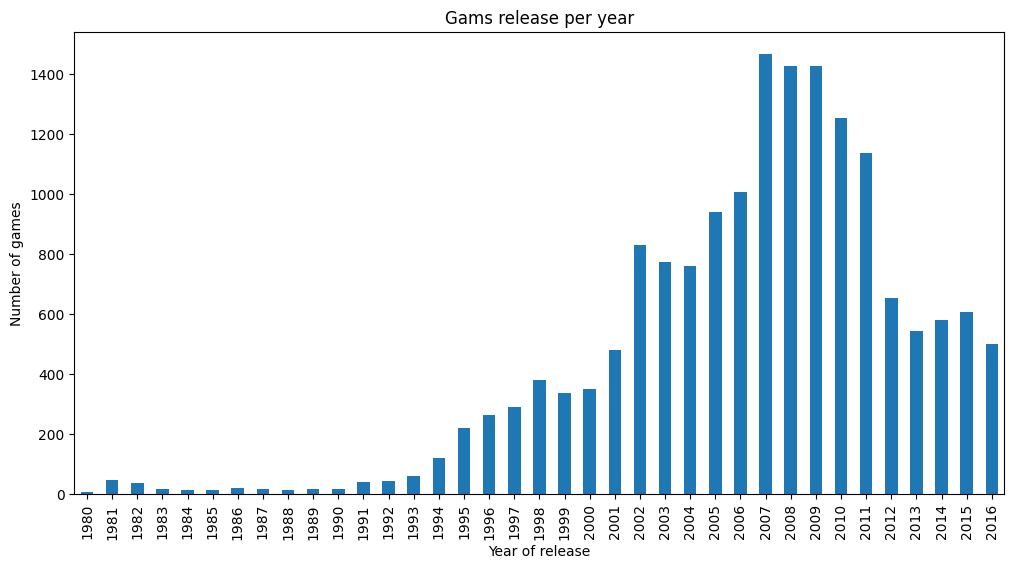

In [21]:
# Visualize the distribution of games across years
import matplotlib.pyplot as plt
plt.figure(figsize = (12 , 6)) 
game_release_per_year.plot(kind='bar', title = 'Gams release per year', xlabel= 'Year of release', ylabel= 'Number of games')
plt.show

In [22]:
# Display summary statistics for each year
game_release_per_year.describe()

count      37.000000
mean      451.756757
std       465.945777
min         9.000000
25%        36.000000
50%       338.000000
75%       762.000000
max      1466.000000
Name: year_of_release, dtype: float64

From the bar chart above, there was growth from 2005 to 2007 which had over 1400 games released. The releases in 2014, 2015 and 2016 could help with the prediction for 2017

### Questions to Consider:
- Which years show significant numbers of game releases?
- Are there any notable trends or patterns in the number of releases?
- Is there enough recent data to make predictions for 2017?

## 3.2 Platform Sales Analysis Over Time

Now let's analyze how sales vary across platforms and years:

In [23]:
# Calculate total sales by platform and year
total_sales_by_platform_year = df.groupby(['platform','year_of_release'])['total_sales'].sum ().reset_index()
total_sales_by_platform_year 

,platform,year_of_release,total_sales
0,2600,1980,11.38
1,2600,1981,35.68
2,2600,1982,28.88
3,2600,1983,5.84
4,2600,1984,0.27
...,...,...,...
239,XB,2008,0.18
240,XOne,2013,18.96
241,XOne,2014,54.07
242,XOne,2015,60.14


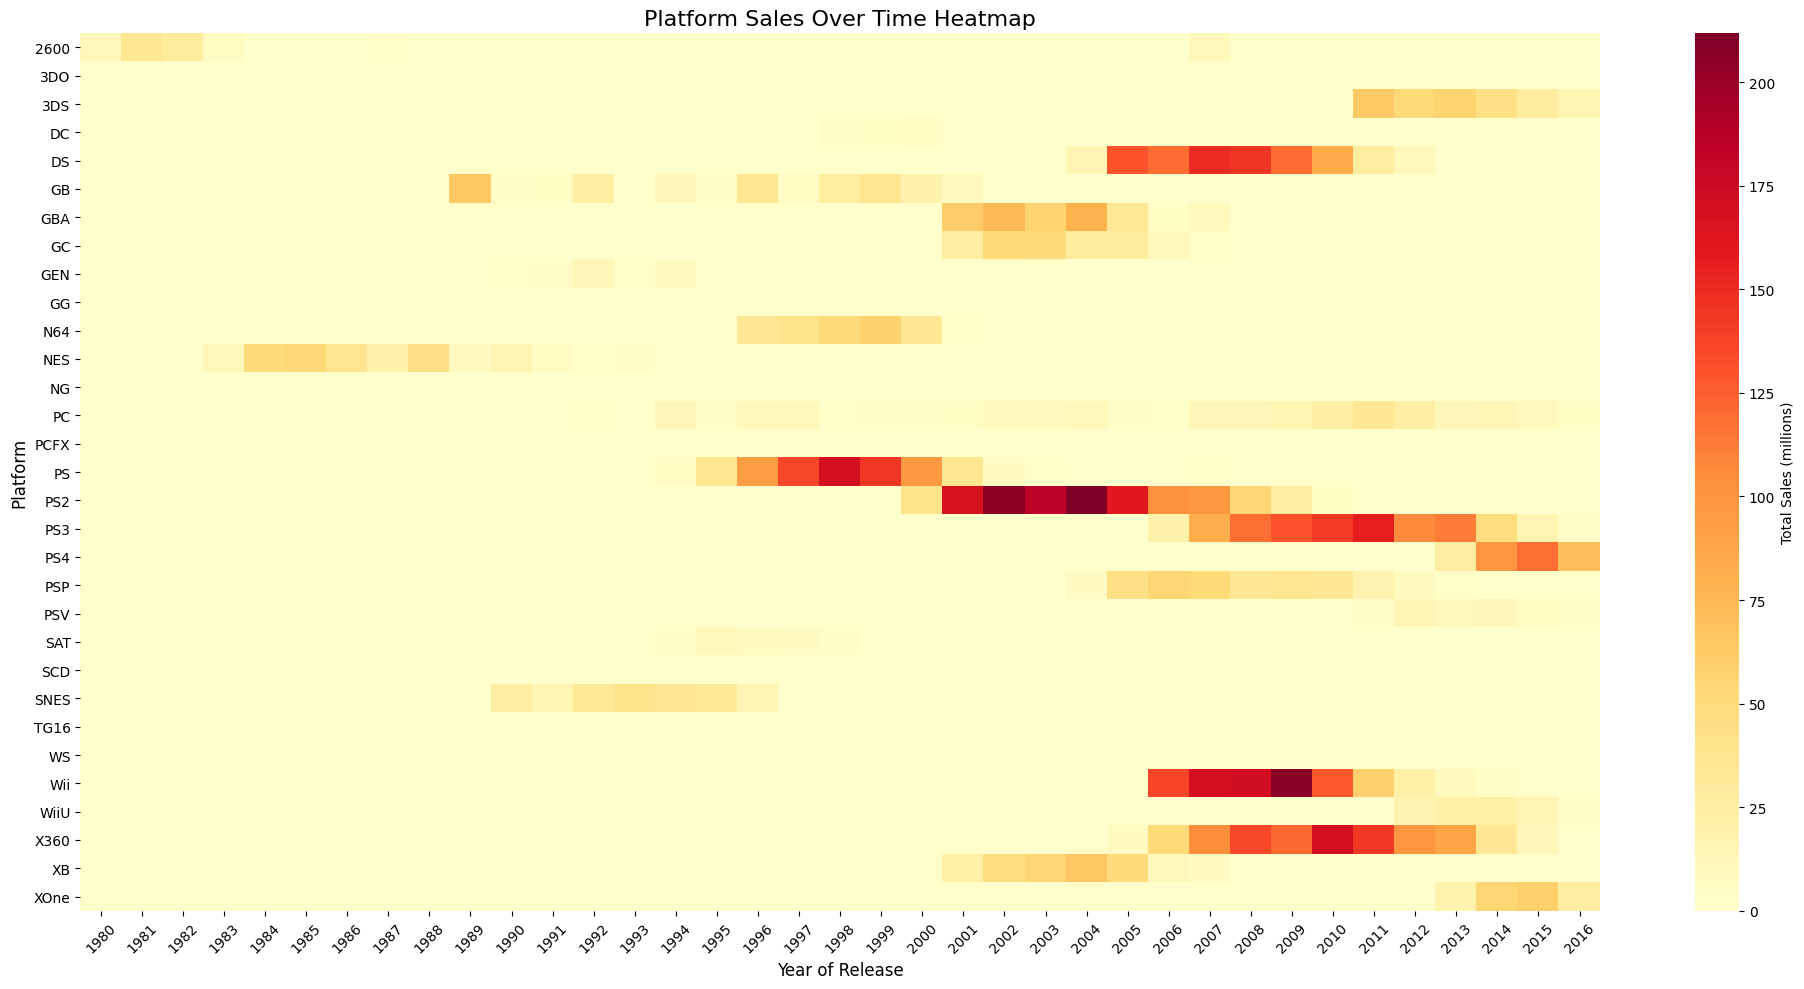

In [24]:
# Create a heatmap of platform sales over time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a pivot table for the heatmap
heatmap_data = total_sales_by_platform_year.pivot(
    index='platform', 
    columns='year_of_release', 
    values='total_sales'
).fillna(0)

# Create the heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(heatmap_data, 
            annot=False,  # Set to True if you want numbers in each cell
            cmap='YlOrRd',  # Color scheme
            cbar_kws={'label': 'Total Sales (millions)'})

plt.title('Platform Sales Over Time Heatmap', fontsize=16)
plt.xlabel('Year of Release', fontsize=12)
plt.ylabel('Platform', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# Identify platforms with declining sales

def years_declining_platforms(df):
    declining_platforms = []
    
    for platform in df['platform'].unique():
        platform_data = df[df['platform'] == platform].groupby('year_of_release')['total_sales'].sum().sort_index()
        
        if len(platform_data) >= 3:  # Need at least 3 years of data
            # Calculate year-over-year changes
            year_over_year_changes = platform_data.pct_change().dropna()
            
            # Check if majority of recent years show decline
            recent_changes = year_over_year_changes.tail(3)  # Last 3 years
            declining_years = (recent_changes < 0).sum()
            
            if declining_years >= 2:  # 2 out of 3 years declining
                avg_decline = recent_changes.mean() * 100
                declining_platforms.append({
                    'platform': platform,
                    'avg_decline_rate': avg_decline,
                    'years_analyzed': len(recent_changes)
                })
    
    return pd.DataFrame(declining_platforms).sort_values('avg_decline_rate')
declining_platforms_result = years_declining_platforms(df)
print(declining_platforms_result)


   platform  avg_decline_rate  years_analyzed
6       PS2        -73.892683               3
4      X360        -71.215004               3
3        DS        -71.054986               3
0       Wii        -70.051704               3
12       XB        -69.977587               3
15      PSP        -67.174813               3
5       PS3        -67.068989               3
2        GB        -63.363893               3
7      SNES        -51.125789               3
20      SAT        -51.060721               3
17       GC        -47.153386               3
9       3DS        -34.887413               3
16     WiiU        -31.964423               3
11       PS        -30.590064               3
8       GBA        -27.474416               3
1       NES        -27.407928               3
19      PSV        -22.369610               3
13       PC        -22.317955               3
18       DC        -22.000215               3
21       NG         50.835137               3
10      N64        183.176268     

Considering the data above,  the PS2, X360, OS and Wii has high average decline rate of over 70% which makes them the top platforms to disappear.

In [26]:
# Calculate variance in sales for each platform over time
def find_consistent_platforms(df):
    consistent_platforms = []
    
    for platform in df['platform'].unique():
        platform_data = df[df['platform'] == platform].groupby('year_of_release')['total_sales'].sum()
        
        if len(platform_data) >= 3:  # Need at least 3 years of data
            # Calculate variance in sales
            sales_variance = platform_data.var()
            # Calculate coefficient of variation (variance relative to mean)
            cv = platform_data.std() / platform_data.mean() if platform_data.mean() > 0 else float('inf')
            
            consistent_platforms.append({
                'platform': platform,
                'sales_variance': sales_variance,
                'coefficient_variation': cv,
                'years_of_data': len(platform_data)
            })
    
    return pd.DataFrame(consistent_platforms).sort_values('coefficient_variation')
consistent_platforms_result = find_consistent_platforms(df)
print(consistent_platforms_result)

   platform  sales_variance  coefficient_variation  years_of_data
24       WS        0.040133               0.423239              3
18     WiiU       49.960070               0.429994              5
17     XOne      412.657667               0.510017              4
9       PS4     1645.755900               0.516558              4
10      3DS      527.759367               0.620892              7
5       PS3     2972.466062               0.638241             11
19       GC      335.413781               0.644448              7
20      GEN       17.860430               0.686734              5
22      PSV       29.475262               0.702863              7
23      SAT       15.741777               0.708709              6
4      X360     3341.424433               0.714069             12
6       PS2     6238.126675               0.754742             12
7      SNES      239.620049               0.773829             10
14       PC       64.338894               0.803599             26
8       GB

Using the above variance, the most consistent platforms , have the lowest coefficient of variation, which is WonderSwan -0.42, followed by WiiU, XOne, and PS4. The least consistent  has the highest coefficient of variation, which is Atari 2600 with 1.40 coefficient

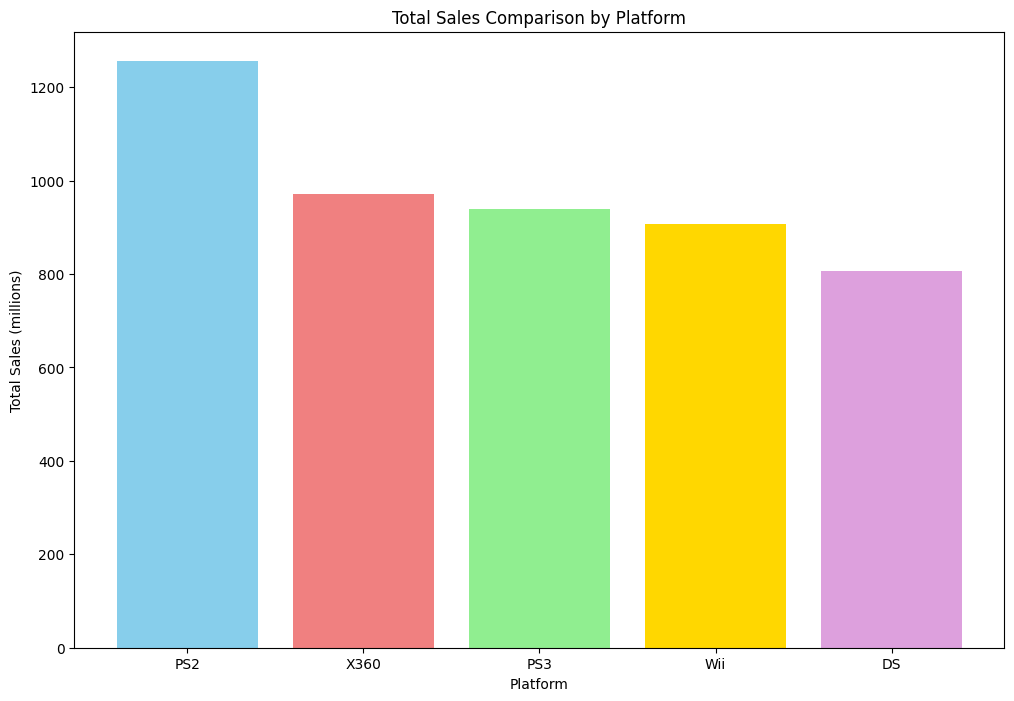

In [27]:
# Compare multiple platform lifecycles
import matplotlib.pyplot as plt
def platform_total_sales_bar_chart(df, platforms):
   
    plt.figure(figsize=(12, 8))
    
    # Calculate total sales for each platform
    platform_totals = []
    for platform in platforms:
        total_sales = df[df['platform'] == platform]['total_sales'].sum()
        platform_totals.append(total_sales)
  
    platforms_to_compare = ['PS2', 'X360', 'PS3', 'Wii', 'DS']
   
    
    # Create bar chart
    plt.bar(platforms, platform_totals, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum'])
    plt.title('Total Sales Comparison by Platform')
    plt.xlabel('Platform')
    plt.ylabel('Total Sales (millions)')
    plt.show()

platform_total_sales_bar_chart(df, ['PS2', 'X360', 'PS3', 'Wii', 'DS'])

### Questions to Consider:
- Which platforms show consistent sales over time?
- Can you identify platforms that have disappeared from the market?
- What's the typical lifecycle of a gaming platform?

## 3.3 Determining Relevant Time Period

Based on your analysis above, determine the appropriate time period for predicting 2017 sales:

In [28]:
print("Year range:", df['year_of_release'].min(), "to", df['year_of_release'].max())

Year range: 1980 to 2016


In [29]:
yearly_counts = df['year_of_release'].value_counts().sort_index()
print(yearly_counts)

1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1466
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: int64


In [30]:

# Your code here to filter the dataset to relevant years
# Example:
relevant_years = [2011, 2013, 2016] # Replace with your chosen years
df_relevant = df[df['year_of_release'].isin(relevant_years)]
df_relevant


# Justify your choice with data


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
29,Call of Duty: Modern Warfare 3,X360,2011,Shooter,9.04,4.24,0.13,1.32,88.0,3.4,M,14.73
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60
37,Call of Duty: Modern Warfare 3,PS3,2011,Shooter,5.54,5.73,0.49,1.57,88.0,3.2,M,13.33
...,...,...,...,...,...,...,...,...,...,...,...,...
16702,STORM: Frontline Nation,PC,2011,Strategy,0.00,0.01,0.00,0.00,60.0,7.2,E10+,0.01
16703,Strawberry Nauts,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01


Looking at the gaming pattern, in order to predict for 2017, from 1980 to 2010 might be too old for the prediction, At the peak in 2007, there has been a steady decrease. For the year 2011, there was a drastic decrease in the pattern, the gaming pattern dropped till 2013, then picked up in 2014 and dropped in 2016. In 2016, 2011 and 2016, the total sale  for some genre declined to 0.01

### Document Your Decision:
- What years did you select and why?
- How does this period reflect current market conditions?
- What factors influenced your decision?

## 3.4 Platform Performance Analysis

Using your selected time period, let's analyze platform performance:

In [31]:
# Analyze platform sales trends using market share by year
yearly_totals = df_relevant.groupby('year_of_release')['total_sales'].sum()
platform_yearly = df_relevant.groupby(['platform', 'year_of_release'])['total_sales'].sum()

# Calculate market share percentage
market_share = platform_yearly.div(yearly_totals, level='year_of_release') * 100
market_share_percentage = market_share.unstack(level=0, fill_value=0)


print(market_share_percentage)
# the below shows the market share, which is percentage of total game sales per year


platform               3DS        DS        PC       PS2        PS3  \
year_of_release                                                       
2011             12.451239  5.157808  6.901375  0.088656  30.887742   
2013             15.659949  0.426309  3.427084  0.000000  31.350349   
2016             11.651531  0.000000  4.040326  0.000000   2.770509   

platform               PS4       PSP       PSV        Wii      WiiU  \
year_of_release                                                       
2011              0.000000  3.510777  0.912171  11.751842  0.000000   
2013              7.194663  0.869228  2.931569   2.377920  5.993245   
2016             53.293828  0.000000  3.270740   0.138525  3.540095   

platform              X360       XOne  
year_of_release                        
2011             28.338390   0.000000  
2013             24.521094   5.248588  
2016              1.169771  20.124673  


In [32]:
# Sort platforms by total sales
platform_totals = df_relevant.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
platform_totals

platform
PS3     273.63
X360    233.94
3DS     134.91
PS4      95.24
Wii      68.42
PC       52.66
XOne     45.11
DS       27.72
WiiU     26.25
PSP      20.96
PSV      19.47
PS2       0.45
Name: total_sales, dtype: float64

In [33]:
# Visualize top platforms
platform_totals.head(10)


platform
PS3     273.63
X360    233.94
3DS     134.91
PS4      95.24
Wii      68.42
PC       52.66
XOne     45.11
DS       27.72
WiiU     26.25
PSP      20.96
Name: total_sales, dtype: float64

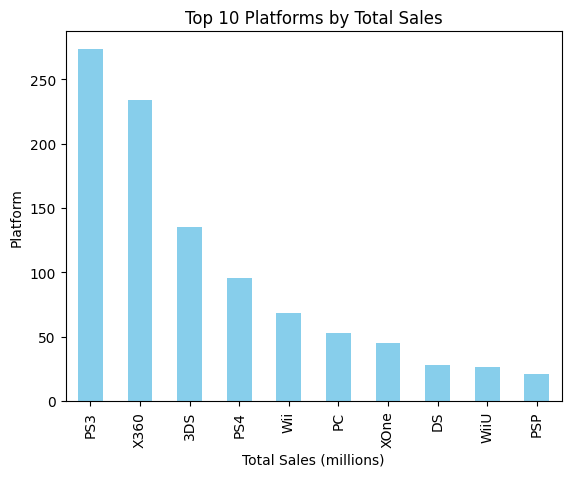

In [34]:
# using bar chart to visualize top 10

top_10_platforms = platform_totals.head(10)
top_10_platforms.plot(kind='bar', color='skyblue')
plt.title('Top 10 Platforms by Total Sales')
plt.xlabel('Total Sales (millions)')
plt.ylabel('Platform')

plt.show()



In [35]:
# Calculate year-over-year growth for each platform using percentage 


platform_year_sales = df_relevant.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()
pivot_sales = platform_year_sales.pivot(index='year_of_release', columns='platform', values='total_sales').fillna(0)
percentage_growth = pivot_sales.pct_change() * 100
percentage_growth




platform,3DS,DS,PC,PS2,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
year_of_release,,,,,,,,,,,,
2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013,-10.490506,-94.117647,-64.658864,-100.0,-27.765021,inf,-82.379349,128.725702,-85.599329,inf,-38.417686,inf
2016,-73.236698,-100.000000,-57.592892,NaN,-96.821192,166.448634,-100.000000,-59.867800,-97.904540,-78.752887,-98.284037,37.921941


<Figure size 1400x800 with 0 Axes>

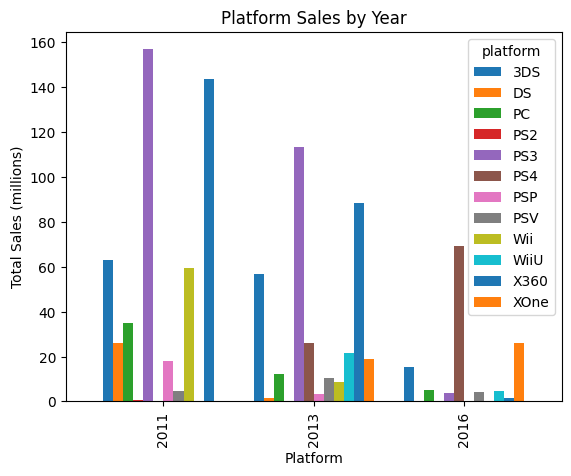

In [36]:
# visualize platform growth rates
plt.figure(figsize=(14, 8))
pivot_sales.plot(kind='bar', width=0.8)
plt.title('Platform Sales by Year')
plt.xlabel('Platform')
plt.ylabel('Total Sales (millions)')

plt.show()

## 3.5 Sales Distribution Analysis

Let's examine the distribution of sales across platforms:

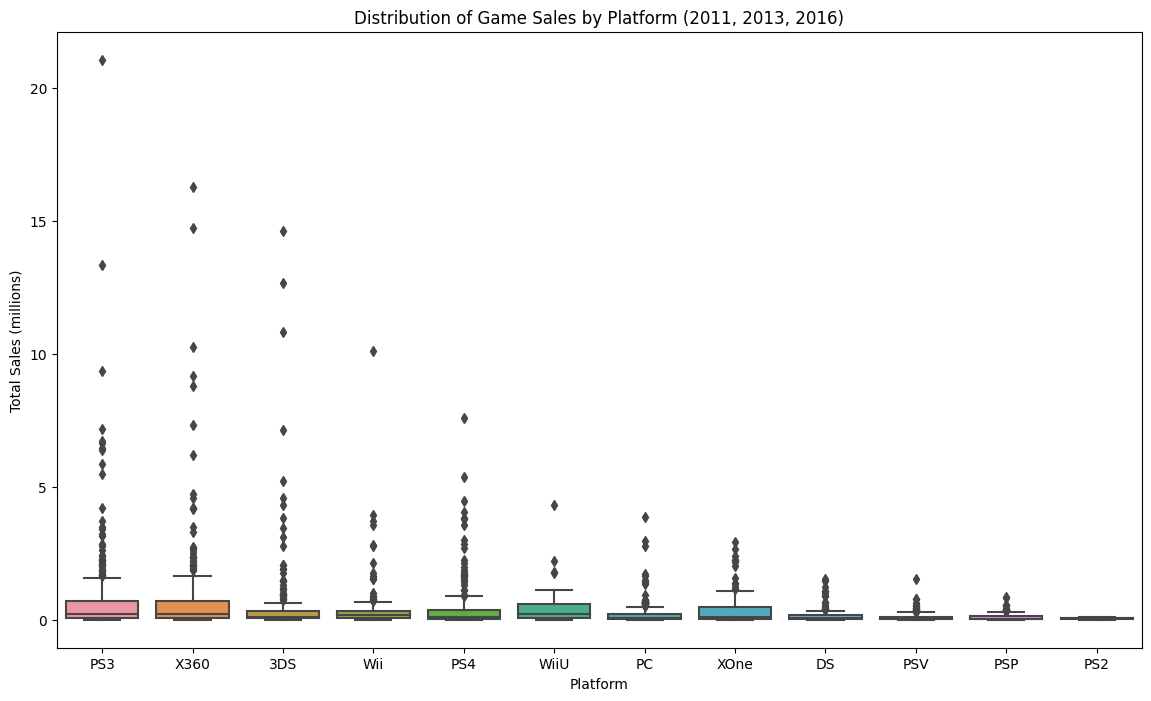

In [37]:
# Create box plot of sales by platform

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_relevant, x='platform', y='total_sales')
plt.title('Distribution of Game Sales by Platform (2011, 2013, 2016)')
plt.xlabel('Platform')
plt.ylabel('Total Sales (millions)')


plt.show()


The horizontal line in each box shows the median of sales for the selected years (2011, 2013, 2016) The PS3 and X360 has the higest median sales. DS, PC. PSV, PS2 and PSP has lower median sales. PS3, x360 and 30s has the most outlier which means they can drive exceptional sales by engaging large audience. The markets are mature

In [38]:
# Calculate detailed statistics for each platform
platform_stats = df_relevant.groupby('platform')['total_sales'].describe()
platform_stats

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
3DS,253.0,0.533241,1.580657,0.01,0.0600,0.130,0.3400,14.60
DS,161.0,0.172174,0.260016,0.01,0.0400,0.080,0.1700,1.54
PC,231.0,0.227965,0.452343,0.01,0.0300,0.070,0.2150,3.88
PS2,7.0,0.064286,0.042762,0.01,0.0350,0.060,0.0900,0.13
PS3,379.0,0.721979,1.676988,0.01,0.0900,0.230,0.6950,21.05
PS4,180.0,0.529111,1.050564,0.01,0.0300,0.100,0.3825,7.60
PSP,193.0,0.108601,0.134244,0.01,0.0200,0.050,0.1400,0.87
PSV,166.0,0.117289,0.180092,0.01,0.0200,0.060,0.1300,1.54
Wii,156.0,0.438590,1.018664,0.01,0.0900,0.170,0.3400,10.12


## 3.6 Review Score Impact Analysis

Select a popular platform and analyze how reviews affect sales:

In [39]:
# Choose a popular platform based on your previous analysis
# choosing from the top 10 platforms, the PS3 would be choosen becauue it has the highest total sales, strong market share but declined in 2016

PS3 games with complete score data: 213


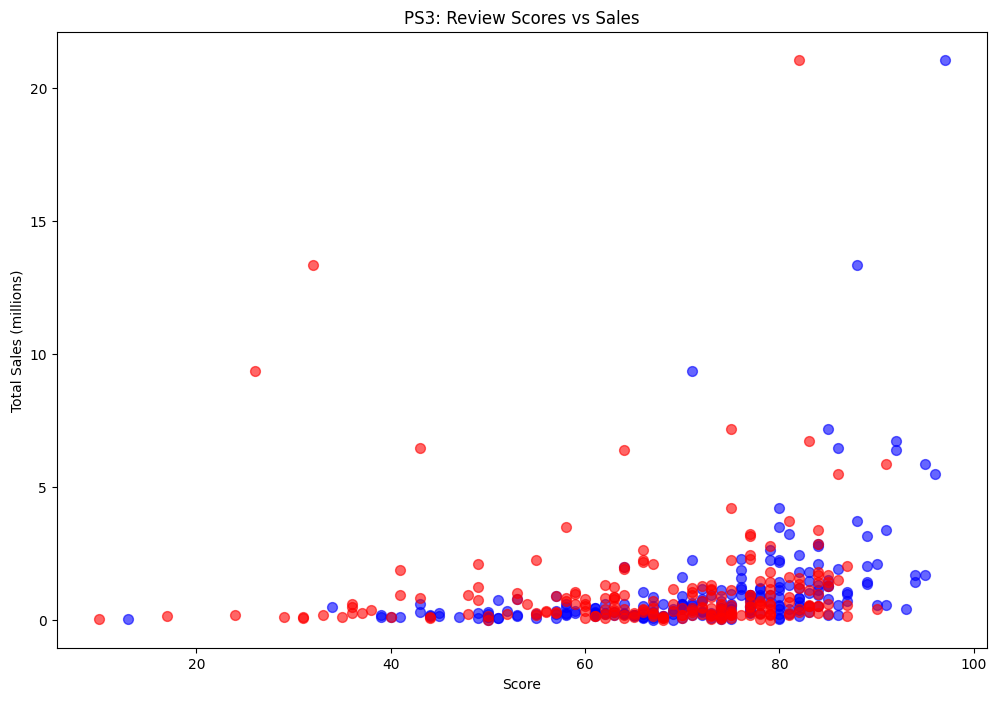

In [40]:
# Create scatter plots for both critic and user scores
# Filter data for PS3 platform
ps3_data = df_relevant[df_relevant['platform'] == 'PS3'].copy()

# Remove rows with missing scores for cleaner analysis
ps3_clean = ps3_data.dropna(subset=['critic_score', 'user_score'])

print(f"PS3 games with complete score data: {len(ps3_clean)}")
# Plot both scores on same chart with different colors
plt.figure(figsize=(12, 8))
plt.scatter(ps3_clean['critic_score'], ps3_clean['total_sales'], 
           alpha=0.6, color='blue', label='Critic Score', s=50)
plt.scatter(ps3_clean['user_score']*10, ps3_clean['total_sales'], 
           alpha=0.6, color='red', label='User Score (x10)', s=50)

plt.xlabel('Score')
plt.ylabel('Total Sales (millions)')
plt.title('PS3: Review Scores vs Sales')

plt.show()



In [41]:
user_correlation = ps3_clean['user_score'].corr(ps3_clean['total_sales'])
user_correlation
# this result shows weak positive correlation between user scores and sales

0.028610089768976436

In [42]:
# Critic Scores



# User Scores

# Calculate correlations
critic_correlation = ps3_clean['critic_score'].corr(ps3_clean['total_sales'])
critic_correlation
# the result shows positive correlation between critic scores and sales which shows critic score plays an important role  in slaes


0.3992002954228515

PS3 was selected for this analysis and the relationship between the sales and the scores were reviewed. dropna() was used to address the missing value so that the analysis would not be affected. The result shows there is a moderate positive  correlation between the critic score and total sales, so the critic score does matter in the total sales of PS3.  The user score is 0.029. This is quite low , which means user scores have almost no relationship with sales successes

## 3.7 Cross-Platform Comparison

Compare sales performance of games across different platforms:

In [43]:
# Find games released on multiple platforms
games_multiple_platforms_count = df_relevant.groupby('name')['platform'].nunique().reset_index()
games_multiple_platforms_count.columns = ['name', 'platform_count']

multi_platform_games = games_multiple_platforms_count[games_multiple_platforms_count['platform_count'] > 1]
print(f"Games released on multiple platforms: {len(multi_platform_games)}")
multi_platform_games.head()

Games released on multiple platforms: 423


,name,platform_count
1,Frozen: Olaf's Quest,2
10,7 Days to Die,2
21,Accel World: Kasoku no Chouten,2
24,Ace Combat: Assault Horizon,2
27,Adventure Time: Explore the Dungeon Because I ...,4


In [44]:
# Compare sales across platforms for these games


multi_platform_names = multi_platform_games['name'].tolist()
multi_platform_data = df_relevant[df_relevant['name'].isin(multi_platform_names)]


avg_sales_by_platform = multi_platform_data.groupby('platform')['total_sales'].mean().sort_values(ascending=False)
avg_sales_by_platform




platform
X360    0.875622
PS3     0.791891
PS4     0.591493
Wii     0.422353
XOne    0.390316
PC      0.276050
WiiU    0.259118
DS      0.251591
3DS     0.232787
PSP     0.193448
PSV     0.130278
PS2     0.084000
Name: total_sales, dtype: float64

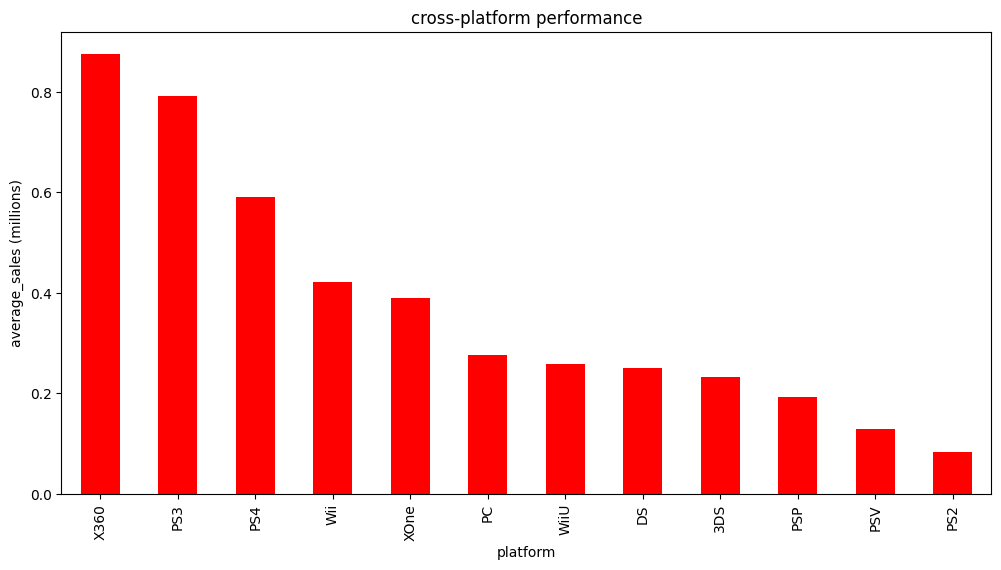

In [45]:
# Your code here to analyze and visualize cross-platform performance




plt.figure(figsize=(12, 6))
avg_sales_by_platform.plot( kind='bar',
        title='cross-platform performance',
        xlabel='platform',
        ylabel='average_sales (millions)',
        color= 'red'
)


plt.show()





In [46]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


## 3.8 Genre Analysis

Finally, let's examine the distribution of games by genre:

In [62]:

# Analyze genre performance , calculating the percentage of the total sales each genre represents


total_sales_per_genre  = df_relevant.groupby('genre')['total_sales'].sum()
total_sales_all_games = df_relevant['total_sales'].sum()
percentage_performance = total_sales_per_genre. div(total_sales_all_games) * 100
percentage_performance






genre
Action          26.963435
Adventure        2.555168
Fighting         3.401218
Misc             8.235212
Platform         5.551884
Puzzle           0.593736
Racing           5.003204
Role-Playing    11.560335
Shooter         19.868637
Simulation       2.569186
Sports          12.088990
Strategy         1.608995
Name: total_sales, dtype: float64

The genres are Action, sports, role_playing and shooter are high performing genre

In [63]:
# Sort genres by total sales
total_sales_per_genre_sorted  = df_relevant.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
total_sales_per_genre_sorted

genre
Action          269.30
Shooter         198.44
Sports          120.74
Role-Playing    115.46
Misc             82.25
Platform         55.45
Racing           49.97
Fighting         33.97
Simulation       25.66
Adventure        25.52
Strategy         16.07
Puzzle            5.93
Name: total_sales, dtype: float64

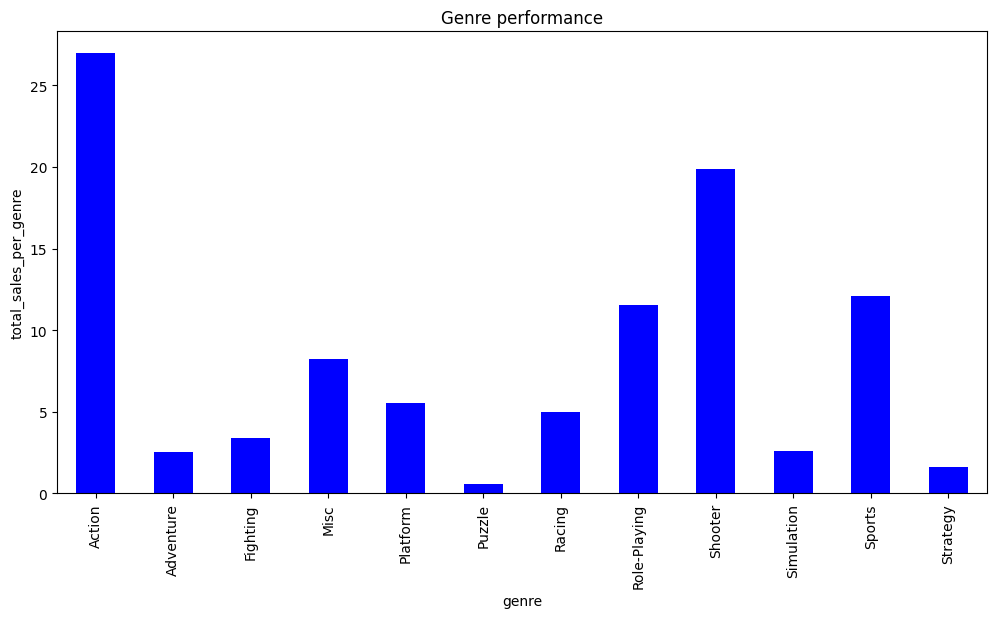

In [64]:
# Visualize genre distribution

plt.figure(figsize=(12, 6))
percentage_performance.plot( kind='bar',
        title='Genre performance',
        xlabel='genre',
        ylabel='total_sales_per_genre',
        color= 'blue'
)


plt.show()



In [65]:
# Calculate market share for each genre
total_sales_per_genre  = df_relevant.groupby('genre')['total_sales'].sum()
total_sales_all_games = df_relevant['total_sales'].sum()
market_share = total_sales_per_genre. div(total_sales_all_games) * 100
market_share

genre
Action          26.963435
Adventure        2.555168
Fighting         3.401218
Misc             8.235212
Platform         5.551884
Puzzle           0.593736
Racing           5.003204
Role-Playing    11.560335
Shooter         19.868637
Simulation       2.569186
Sports          12.088990
Strategy         1.608995
Name: total_sales, dtype: float64

### Key Questions for Genre Analysis:
- Which genres consistently perform well?
- Are there any genres showing recent growth or decline?
- How does the average performance vary across genres?

# Step 4: Regional Market Analysis and User Profiles

In this section, we will analyze the gaming market characteristics across three major regions: North America (NA), Europe (EU), and Japan (JP). Our analysis will focus on platform preferences, genre popularity, and the impact of ESRB ratings in each region.

## 4.1 Regional Platform Analysis

Let's begin by examining platform performance across different regions:

In [51]:
# Function to analyze platform performance by region

def platform_sales_by_region(df):
    columns = ['platform', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales']
    by_platform = df[columns].groupby('platform', as_index=False).sum()
    
    return {
      'NA': by_platform[['platform', 'na_sales']].sort_values('na_sales', ascending=False),
      'EU': by_platform[['platform', 'eu_sales']].sort_values('eu_sales', ascending=False),
      'JP': by_platform[['platform', 'jp_sales']].sort_values('jp_sales', ascending=False),
      'Other': by_platform[['platform', 'other_sales']].sort_values('other_sales', ascending=False)
     }

   
platform_sales_by_region(df)


{'NA':    platform  na_sales
 28     X360    602.47
 16      PS2    583.84
 26      Wii    496.90
 17      PS3    393.49
 4        DS    382.40
 15       PS    336.52
 6       GBA    187.54
 29       XB    186.69
 10      N64    139.02
 7        GC    133.46
 11      NES    125.94
 5        GB    114.32
 19      PSP    109.17
 18      PS4    108.74
 13       PC     94.53
 30     XOne     93.12
 0      2600     90.60
 2       3DS     83.49
 23     SNES     61.23
 27     WiiU     38.10
 8       GEN     21.05
 20      PSV     12.58
 3        DC      5.43
 22      SCD      1.00
 21      SAT      0.72
 1       3DO      0.00
 14     PCFX      0.00
 12       NG      0.00
 9        GG      0.00
 24     TG16      0.00
 25       WS      0.00,
 'EU':    platform  eu_sales
 16      PS2    339.29
 17      PS3    330.29
 28     X360    270.76
 26      Wii    262.21
 15       PS    213.61
 4        DS    188.89
 13       PC    142.44
 18      PS4    141.09
 6       GBA     75.25
 19      PSP     66.6

In [52]:
# Analyze each region
platform_sales_by_region(df.head(5))

{'NA':   platform  na_sales
 2      Wii     72.65
 1      NES     29.08
 0       GB     11.27,
 'EU':   platform  eu_sales
 2      Wii     52.65
 0       GB      8.89
 1      NES      3.58,
 'JP':   platform  jp_sales
 2      Wii     10.84
 0       GB     10.22
 1      NES      6.81,
 'Other':   platform  other_sales
 2      Wii        14.69
 0       GB         1.00
 1      NES         0.77}

### Cross-Regional Platform Comparison

Let's create a comparative analysis of platform performance across regions:

In [66]:
# Create a comparative platform analysis


platform_sales_by_region(df_relevant.head(5))

      

{'NA':   platform  na_sales
 2     X360     18.70
 1      PS3     12.56
 0      3DS      5.28,
 'EU':   platform  eu_sales
 1      PS3     14.82
 2     X360      9.38
 0      3DS      4.19,
 'JP':   platform  jp_sales
 0      3DS      4.35
 1      PS3      1.47
 2     X360      0.19,
 'Other':   platform  other_sales
 1      PS3         5.53
 2     X360         2.73
 0      3DS         0.78}

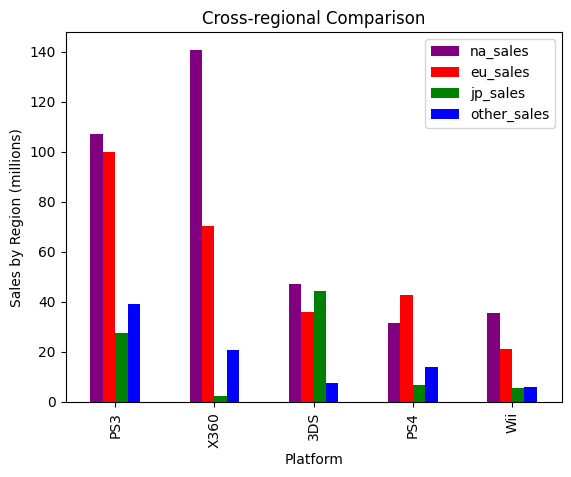

In [67]:
# Visualize cross-regional comparison for top platforms

platform_regional = df_relevant.groupby('platform')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()
top_platforms = platform_regional.sum(axis=1).nlargest(5).index
platform_regional.loc[top_platforms].plot(kind='bar',
                                         title='Cross-regional Comparison', 
                                         xlabel='Platform',
                                         ylabel='Sales by Region (millions)',
                                         color=['purple', 'red', 'green','blue'])
plt.show()



In [55]:
df.columns


Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating',
       'total_sales'],
      dtype='object')

## 4.2 Regional Genre Analysis

Now let's examine genre preferences across regions:

In [68]:
# Function to analyze genre performance by region

def genre_performance_by_region(df_relevant):
    columns = ['genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales']
    by_genre = df_relevant[columns].groupby('genre', as_index=False).sum()
    
    return {
      'NA': by_genre[['genre', 'na_sales']].sort_values('na_sales', ascending=False),
      'EU': by_genre[['genre', 'eu_sales']].sort_values('eu_sales', ascending=False),
      'JP': by_genre[['genre', 'jp_sales']].sort_values('jp_sales', ascending=False),
      'Other': by_genre[['genre', 'other_sales']].sort_values('other_sales', ascending=False)
     }

   
genre_performance_by_region(df_relevant)


{'NA':            genre  na_sales
 0         Action    115.89
 8        Shooter     96.62
 10        Sports     53.85
 3           Misc     44.70
 7   Role-Playing     38.60
 4       Platform     25.54
 6         Racing     19.71
 2       Fighting     16.80
 9     Simulation      9.79
 1      Adventure      8.29
 11      Strategy      5.79
 5         Puzzle      1.79,
 'EU':            genre  eu_sales
 0         Action     93.91
 8        Shooter     72.79
 10        Sports     46.19
 7   Role-Playing     26.85
 3           Misc     21.24
 6         Racing     21.12
 4       Platform     18.83
 9     Simulation     10.06
 2       Fighting      8.65
 1      Adventure      7.58
 11      Strategy      5.87
 5         Puzzle      2.65,
 'JP':            genre  jp_sales
 7   Role-Playing     40.92
 0         Action     28.80
 3           Misc      9.37
 1      Adventure      7.23
 10        Sports      6.15
 4       Platform      5.71
 8        Shooter      5.49
 2       Fighting      4.97


### Cross-Regional Genre Comparison

Let's compare genre preferences across regions:

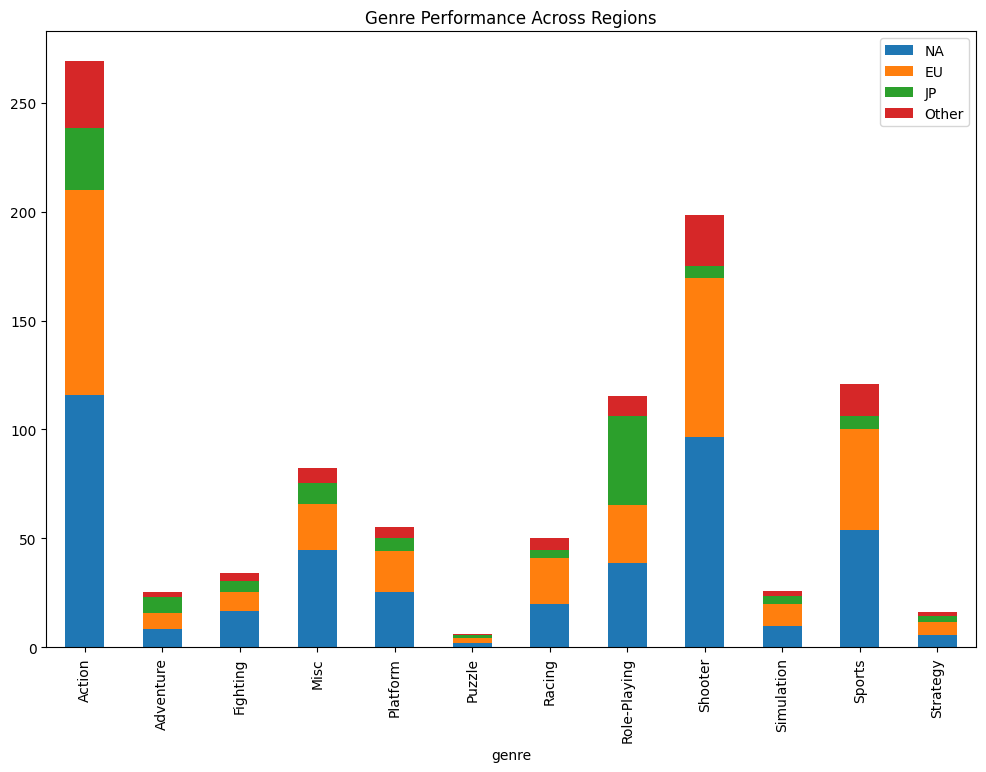

In [69]:
# Create a comparative genre analysis
genre_data = genre_performance_by_region(df_relevant)

regional_comparison = pd.DataFrame({
    'NA': genre_data['NA'].set_index('genre')['na_sales'],
    'EU': genre_data['EU'].set_index('genre')['eu_sales'], 
    'JP': genre_data['JP'].set_index('genre')['jp_sales'],
    'Other': genre_data['Other'].set_index('genre')['other_sales']
}).fillna(0)
regional_comparison.plot(kind='bar', stacked=True, 
                        figsize=(12, 8),
                        title='Genre Performance Across Regions')
plt.show()

## 4.3 ESRB Rating Impact Analysis

Finally, let's examine how ESRB ratings affect sales in each region:

In [70]:
# Function to analyze ESRB rating impact

def ESRB_rating_by_region(df_relevant):
    columns = ['rating', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales']
    by_rating = df_relevant[columns].groupby('rating', as_index=False).sum()
    
    return {
      'NA': by_rating[['rating', 'na_sales']].sort_values('na_sales', ascending=False),
      'EU': by_rating[['rating', 'eu_sales']].sort_values('eu_sales', ascending=False),
      'JP': by_rating[['rating', 'jp_sales']].sort_values('jp_sales', ascending=False),
      'Other': by_rating[['rating', 'other_sales']].sort_values('other_sales', ascending=False)
     }

   
ESRB_rating_by_region(df_relevant)

{'NA':   rating  na_sales
 3      M    161.34
 0      E     92.08
 1   E10+     66.84
 5      T     63.08
 2     EC      0.42
 4     RP      0.00,
 'EU':   rating  eu_sales
 3      M    124.72
 0      E     67.61
 5      T     47.87
 1   E10+     42.97
 4     RP      0.03
 2     EC      0.00,
 'JP':   rating  jp_sales
 0      E     15.62
 5      T     15.45
 3      M     12.24
 1   E10+      4.92
 2     EC      0.00
 4     RP      0.00,
 'Other':   rating  other_sales
 3      M        41.89
 0      E        19.73
 5      T        16.30
 1   E10+        13.48
 2     EC         0.03
 4     RP         0.01}

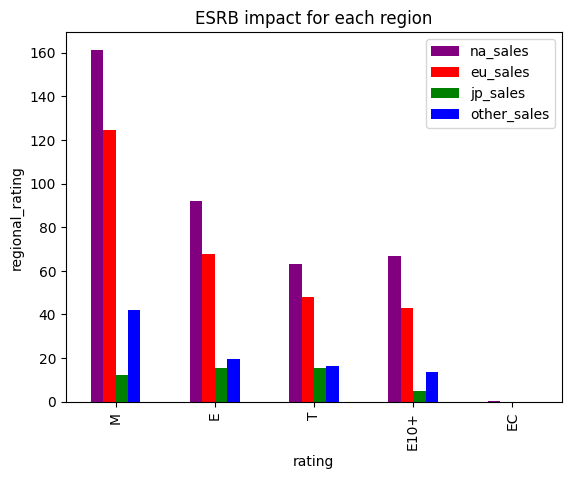

In [71]:
# Analyze ESRB impact for each region

regional_rating = df_relevant.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()
top_rating = regional_rating.sum(axis=1).nlargest(5).index
regional_rating.loc[top_rating].plot(kind='bar',
                                         title='ESRB impact for each region', 
                                         xlabel='rating',
                                         ylabel='regional_rating',
                                         color=['purple', 'red', 'green', 'blue'])
plt.show()



From the above analysis, the North America and Europe  has high M and E rating. M rating has the highest regional rating. 

In [74]:
print("\nSample games by rating:")
for rating in df_relevant['rating'].dropna().unique():
    sample_games = df_relevant[df_relevant['rating'] == rating]['name'].head(3)
    print(f"{rating}: {list(sample_games)}")


Sample games by rating:
M: ['Grand Theft Auto V', 'Grand Theft Auto V', 'Call of Duty: Modern Warfare 3']
E: ['Mario Kart 7', 'Super Mario 3D Land', 'FIFA 17']
E10+: ['Just Dance 3', 'The Legend of Zelda: Skyward Sword', 'Just Dance 2014']
T: ["Uncharted 3: Drake's Deception", 'Batman: Arkham City', "Uncharted 4: A Thief's End"]
EC: ['Nickelodeon Team Umizoomi']
RP: ['Supreme Ruler: Cold War']


# Step 5 : Hypothesis Tests

—Average user ratings of the Xbox One and PC platforms are the same.

—Average user ratings for the Action and Sports genres are different.

Set the *alpha* threshold value yourself.

Explain:

—How you formulated the null and alternative hypotheses

—What criteria you used to test the hypotheses~~,~~ and why


In [75]:
# Test the hypotheses


# Null hypothesis (H0):Average user ratings are no  difference for Xbox One and PC platforms
# Alternative hypothesis (H1):  Average user ratings are difference between Xbox One and PC platforms
# Using two-tailed  t-test because two independent samples are used


from scipy import stats
xbox_ratings = df_relevant[df_relevant['platform'] == 'XOne']['user_score'].dropna()
pc_ratings = df_relevant[df_relevant['platform'] == 'PC']['user_score'].dropna()
alpha = 0.05 
results = stats.ttest_ind(xbox_ratings, pc_ratings)
print('p-value: ', results.pvalue)
if results.pvalue<alpha: 
    print('We reject the null hypothesis')
    print('Average user ratings are different between Xbox One and PC platforms')
else:
    print("We can't reject the null hypothesis")
    print('Average user ratings are the same for Xbox One and PC platforms')







p-value:  0.8114871328042039
We can't reject the null hypothesis
Average user ratings are the same for Xbox One and PC platforms


In [76]:
# Average user ratings for the Action and Sports genres are different.
    
# Null hypothesis (H0):Average user ratings are no  difference for Action and Sports genres
# Alternative hypothesis (H1):  Average user ratings are difference for the Action and Sports genres 
# Using two-tailed  t-test because two independent samples are used



from scipy import stats
Action_ratings = df_relevant[df_relevant['genre'] == 'Action']['user_score'].dropna()
Sports_ratings = df_relevant[df_relevant['genre'] == 'Sports']['user_score'].dropna()
alpha = 0.05 
results = stats.ttest_ind(Action_ratings, Sports_ratings)
print('p-value: ', results.pvalue)
if results.pvalue<alpha: 
    print('We reject the null hypothesis')
    print('Average user ratings are different between action and sports genre')
else:
    print("We can't reject the null hypothesis")
    print('Average user ratings are the same for action and sports genre')



p-value:  6.024341826088959e-10
We reject the null hypothesis
Average user ratings are different between action and sports genre


# Step 6. Write a general conclusion


The analysis was based on the years selected, which are 2011, 2013, and 2016.  The 2011 represent the transition period in gaming. 2013 was chosen as a year the market recovered after the decline from the 2007 peak. 2016 was chosen as recent  data for predicitng 2017 trend. There is strong evidence that average user ratings differ between Xbox One and PC platforms because the p-value is extremely small.
There is no significant difference in average user ratings between Action and Sports genres, here the p-value is greater than alpha.